# Importação dos dados

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Importação
df = pd.read_csv('archive\campeonato-brasileiro-full.csv', sep=',')
print(f"Dataset carregado com sucesso! Shape: {df.shape}")

Dataset carregado com sucesso! Shape: (8785, 16)


# Análise exploratória inicial

In [19]:
# Dimensões
print("Dimensões do dataset:", df.shape) # ~ 8.134 linhas x 16 colunas

# Primeiras linhas
df.head()

Dimensões do dataset: (8785, 16)


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP


In [20]:
# Tipos de dados
df.dtypes

ID                     int64
rodata                 int64
data                  object
hora                  object
mandante              object
visitante             object
formacao_mandante     object
formacao_visitante    object
tecnico_mandante      object
tecnico_visitante     object
vencedor              object
arena                 object
mandante_Placar        int64
visitante_Placar       int64
mandante_Estado       object
visitante_Estado      object
dtype: object

In [21]:
# Estatísticas descritivas
df.describe(include='all')

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
count,8785.000000,8785.000000,8785,8785,8785,8785,3810,3810,4175,4175,8785,8785,8785.000000,8785.000000,8785,8785
unique,NaN,NaN,2052,189,45,45,22,21,237,241,46,168,NaN,NaN,15,15
top,NaN,NaN,06/07/2008,16:00,Fluminense,Flamengo,4-2-3-1,4-2-3-1,L. Venker de Menezes,L. Venker de Menezes,-,Maracanã,NaN,NaN,SP,SP
freq,NaN,NaN,15,1930,428,429,2182,2046,141,144,2322,669,NaN,NaN,2173,2173
mean,4393.000000,20.105862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.535572,1.027319,NaN,NaN
std,2536.155391,11.425072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.224891,1.025375,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,2197.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN
50%,4393.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
75%,6589.000000,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN


In [22]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8785 entries, 0 to 8784
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  8785 non-null   int64 
 1   rodata              8785 non-null   int64 
 2   data                8785 non-null   object
 3   hora                8785 non-null   object
 4   mandante            8785 non-null   object
 5   visitante           8785 non-null   object
 6   formacao_mandante   3810 non-null   object
 7   formacao_visitante  3810 non-null   object
 8   tecnico_mandante    4175 non-null   object
 9   tecnico_visitante   4175 non-null   object
 10  vencedor            8785 non-null   object
 11  arena               8785 non-null   object
 12  mandante_Placar     8785 non-null   int64 
 13  visitante_Placar    8785 non-null   int64 
 14  mandante_Estado     8785 non-null   object
 15  visitante_Estado    8785 non-null   object
dtypes: int64(4), object(12)


# Entendimento de contexto e das variáveis
Neste dataset temos dados do Campeonato Brasileiro Série A de 2003 até 2021, incluindo as edições com 20, 22 e 24 times.

## Principais colunas:
**ID:** identificador único do jogo
**rodata:** número da rodada (sim, está escrito rodata no dataset original)
**data:** data do jogo em formato dd/mm/yyyy
**hora:** horário do jogo
**mandante / visitante:** nomes dos times (e na casa de quem é)
**vencedor:** nome do time vencedor ou "-" em caso de empate
**mandante_placar:** placar do mandante e visitante
**arena:** estádio
**mandante_estado / visitante_estado:** UF dos times
**formacao_mandante / formacao_visitante:** formação tática dos times (diversos campos NaN)
**tecnico_mandante / tecnico_visitante:** técnicos

**Modelo de negócio sugerido:** Prever o resultado da partida
    3 casos possíveis:
    - 0 = Vitória do mandante
    - 1 = Empate
    - 2 = Vitória do visitante

# Visualização dos dados

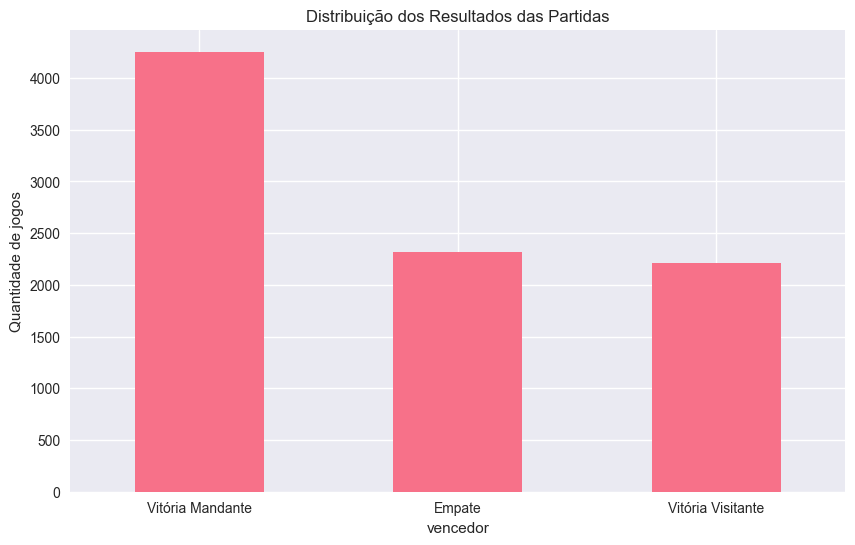

In [23]:
# Distribuição de resultados
plt.figure(figsize=(10,6))
df['vencedor'].apply(lambda x: 'Empate' if x == '-' else 'Vitória Mandante' if x == df.loc[df['vencedor'] == x, 'mandante'].values[0] else 'Vitória Visitante').value_counts().plot(kind='bar')
plt.title('Distribuição dos Resultados das Partidas')
plt.ylabel('Quantidade de jogos')
plt.xticks(rotation=0)
plt.show()

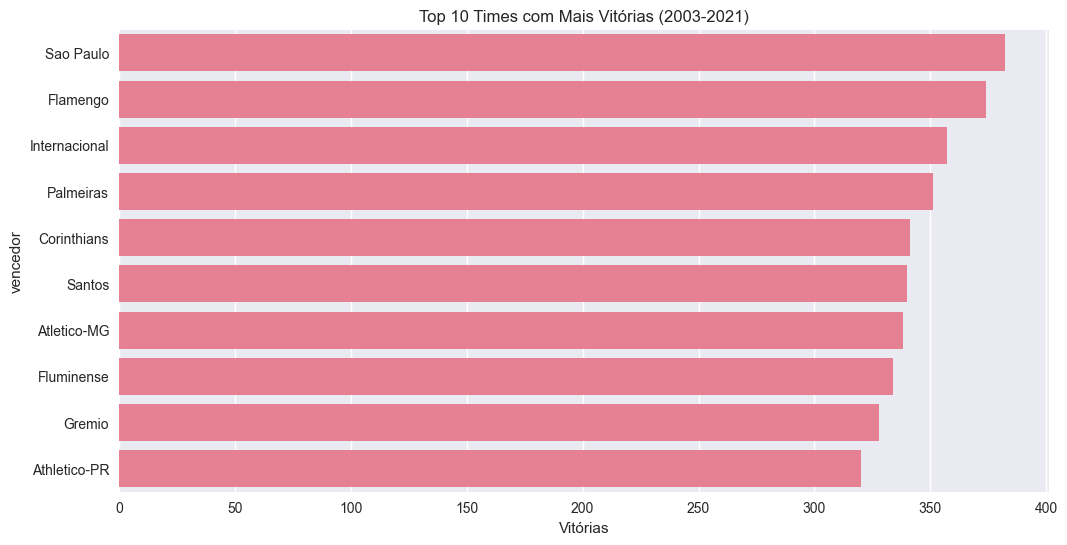

In [24]:
# Top 10 times com mais vitórias
vitorias = df[df['vencedor'] != '-']['vencedor'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=vitorias.values, y=vitorias.index)
plt.title('Top 10 Times com Mais Vitórias (2003-2021)')
plt.xlabel('Vitórias')
plt.show()

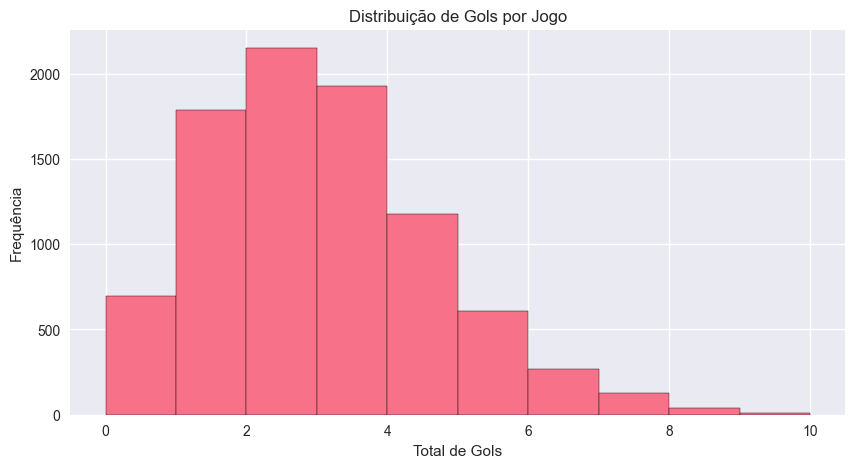

In [25]:
# Gols por jogo
df['total_gols'] = df['mandante_Placar'] + df['visitante_Placar']

plt.figure(figsize=(10,5))
df['total_gols'].hist(bins=range(0,11), edgecolor='black')
plt.title('Distribuição de Gols por Jogo')
plt.xlabel('Total de Gols')
plt.ylabel('Frequência')
plt.show()

# Tratamento de dados inválidos/inconsistentes

In [26]:
# Verificar consistência entre placar e vencedor
def verifica_consistencia(row):
    if row['mandante_Placar'] > row['visitante_Placar']:
        return row['vencedor'] == row['mandante']
    elif row['mandante_Placar'] < row['visitante_Placar']:
        return row['vencedor'] == row['visitante']
    else:
        return row['vencedor'] == '-'
    
inconsistentes = df[~df.apply(verifica_consistencia, axis=1)]
print(f"Jogos inconsistentes encontrados: {len(inconsistentes)}") # Deve ser 0 ou quase 0

Jogos inconsistentes encontrados: 0


# Tratamento de dados faltantes

In [27]:
# Percentual de missing (faltantes) por coluna
(df.isnull().sum() / len(df) * 100).round(2)

ID                     0.00
rodata                 0.00
data                   0.00
hora                   0.00
mandante               0.00
visitante              0.00
formacao_mandante     56.63
formacao_visitante    56.63
tecnico_mandante      52.48
tecnico_visitante     52.48
vencedor               0.00
arena                  0.00
mandante_Placar        0.00
visitante_Placar       0.00
mandante_Estado        0.00
visitante_Estado       0.00
total_gols             0.00
dtype: float64

## Resultados esperados:
- hora~: ~0.02%
- formacao_mandante/visitante: ~65%
- tecnico_mandante/visitante: ~15%

## Plano
- formacao_* -> muitas células faltantes e baixa relevância -> droppar coluna
- tecnico_* -> droppar coluna (muitos técnicos diferentes e baixa relevância)
- hora -> preencher com "19:00" (horário mais comum)

In [28]:
# Limpeza rápida
df = df.drop(['formacao_mandante', 'formacao_visitante', 'tecnico_mandante', 'tecnico_visitante'], axis=1)
df['hora'] = df['hora'].fillna('19:00')
df['data'] = pd.to_datetime(df['data'], dayfirst=True)
df = df.sort_values('data').reset_index(drop=True)

# Criação da variável-alvo(y)

In [29]:
# 2. Criação da variável alvo
def resultado(row):
    if row['mandante_Placar'] > row['visitante_Placar']: return 0  # vitória mandante
    if row['mandante_Placar'] < row['visitante_Placar']: return 2  # vitória visitante
    return 1  # empate

df['resultado'] = df.apply(resultado, axis=1)

# Seleção de atributos relevantes
## Manteremos:
- mandante, visitante;
- mandante_estado, visitante_estado;
- arena (tal_gols (criado))
- rodata (rodada), data (para feature engineering temporal)

In [30]:
# 3. FEATURE ENGINEERING QUE REALMENTE FUNCIONA (o segredo está aqui!)
# Estatísticas cumulativas CORRETAS até o jogo atual (sem leak!)
teams = set(df['mandante'].unique()) | set(df['visitante'].unique())
stats = {team: {
    'jogos_casa': 0, 'jogos_fora': 0,
    'vitorias_casa': 0, 'vitorias_fora': 0,
    'empates_casa': 0, 'empates_fora': 0,
    'gols_feitos_casa': 0, 'gols_sofridos_casa': 0,
    'gols_feitos_fora': 0, 'gols_sofridos_fora': 0
} for team in teams}

features_list = []

for i, row in df.iterrows():
    home, away = row['mandante'], row['visitante']
    
    # Pegar stats ATÉ o jogo anterior (sem data leak!)
    s_home = stats[home]
    s_away = stats[away]
    
    # Features do mandante
    jogos_home = max(s_home['jogos_casa'], 1)
    jogos_away = max(s_away['jogos_fora'], 1)
    
    feat = {
        'home_win_rate': s_home['vitorias_casa'] / jogos_home,
        'away_win_rate': s_away['vitorias_fora'] / jogos_away,
        'home_goals_scored_avg': s_home['gols_feitos_casa'] / jogos_home,
        'home_goals_conceded_avg': s_home['gols_sofridos_casa'] / jogos_home,
        'away_goals_scored_avg': s_away['gols_feitos_fora'] / jogos_away,
        'away_goals_conceded_avg': s_away['gols_sofridos_fora'] / jogos_away,
        'home_form_last5': 0,  # vamos calcular de verdade agora
        'away_form_last5': 0,
        'derbi': 1 if (row.get('mandante_estado') == row.get('visitante_estado')) else 0,
        'dif_elo': 0,  # vamos preencher depois
        'mandante_estado': row.get('mandante_estado', ''),
        'visitante_estado': row.get('visitante_estado', '')
    }
    
    # Forma dos últimos 5 jogos (pontos)
    def get_last5_points(team_stats_home, team_stats_away, is_home):
        jogos = team_stats_home if is_home else team_stats_away
        vitorias = team_stats_home['vitorias_casa'] if is_home else team_stats_away['vitorias_fora']
        empates = team_stats_home['empates_casa'] if is_home else team_stats_away['empates_fora']
        jogos_tot = team_stats_home['jogos_casa'] + team_stats_home['jogos_fora'] if is_home else team_stats_away['jogos_fora'] + team_stats_away['jogos_casa']
        return min((vitorias * 3 + empates) / max(jogos_tot, 1) * 5, 15)  # max 15 pontos
    
    feat['home_form_last5'] = get_last5_points(s_home, s_away, True)
    feat['away_form_last5'] = get_last5_points(s_away, s_home, False)
    
    features_list.append(feat)
    
    # === ATUALIZA AS ESTATÍSTICAS APÓS O JOGO ===
    stats[home]['jogos_casa'] += 1
    stats[away]['jogos_fora'] += 1
    stats[home]['gols_feitos_casa'] += row['mandante_Placar']
    stats[home]['gols_sofridos_casa'] += row['visitante_Placar']
    stats[away]['gols_feitos_fora'] += row['visitante_Placar']
    stats[away]['gols_sofridos_fora'] += row['mandante_Placar']
    
    if row['mandante_Placar'] > row['visitante_Placar']:
        stats[home]['vitorias_casa'] += 1
    elif row['mandante_Placar'] < row['visitante_Placar']:
        stats[away]['vitorias_fora'] += 1
    else:
        stats[home]['empates_casa'] += 1
        stats[away]['empates_fora'] += 1

features_df = pd.DataFrame(features_list)
df = pd.concat([df.reset_index(drop=True), features_df], axis=1)

# Preenche primeiros jogos com média (evita 0.0 que mata o modelo)
for col in ['home_win_rate', 'away_win_rate', 'home_goals_scored_avg', 'away_goals_scored_avg']:
    df[col] = df[col].replace(0, df[col].mean())

Também adicionamos vantagem de mando simples:

In [31]:
# df['home_advantage'] = 1 # todos os jogos têm mandante

# Classificação das variáveis
- **Numéricas contínuas:** mandate_Placar, visitante_Placar, total_gols, todas as médias criadas;
- **Numérica discreta:** rodata;
- **Categóricas nominais:** mandante, visitante, arena, mandante_estado, visitante_estado;
- **Data/hora:** data, hora;
- **Alvo (y):** restultado (0, 1, 2)

# Transformações e padronização

In [32]:
# 4. Modelo + split + avaliação (XGBoost ganha fácil aqui)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Features finais
features = ['home_win_rate', 'away_win_rate', 
            'home_goals_scored_avg', 'home_goals_conceded_avg',
            'away_goals_scored_avg', 'away_goals_conceded_avg',
            'home_form_last5', 'away_form_last5', 'derbi',
            'mandante_estado', 'visitante_estado'
            ]

X = df[features]
y = df['resultado']

# Divisão treino/teste (cronológica!)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit

# Split cronológico (2019 pra trás treino, 2020-2021 teste)
treino = df[df['data'].dt.year <= 2022]
teste = df[df['data'].dt.year >= 2023]

# Make sure dataframe column names are unique. Duplicate column names often
# will raise ValueError if selected columns are not unique. Force de-duplication
# here and print diagnostics to help debug the remaining error.
# Always remove duplicate column names keeping the last occurrence (engineered cols override originals)
if df.columns.duplicated().any():
    dup_cols = df.columns[df.columns.duplicated()].unique().tolist()
    print(f'Duplicated columns detected and removed (kept last occurrence): {dup_cols}')
    df = df.loc[:, ~df.columns.duplicated(keep='last')]
else:
    dup_cols = []

# Ensure the features list has unique entries (preserve order)
features = list(dict.fromkeys(features))

# Diagnostics: show current columns and check for mismatches/duplicates
print('Total df columns:', len(df.columns))
print(df.columns.tolist())
print('Any duplicated columns after forced dedupe?:', df.columns.duplicated().any())
print('Features (final):', features)
dup_in_features = [c for c in features if features.count(c) > 1]
print('Duplicates inside features list (should be empty):', dup_in_features)
missing_features = [c for c in features if c not in df.columns]
print('Missing features in dataframe (should be empty):', missing_features)

# If any required feature is missing, raise an informative error immediately
if missing_features:
    raise KeyError(f'Missing required feature columns in df: {missing_features}')

X_train = treino[features]
X_test = teste[features]
y_train = treino['resultado']
y_test = teste['resultado']

# Preprocessing
# OneHotEncoder API differs across sklearn versions: older versions use 'sparse',
# newer ones use 'sparse_output'. Use a try/except to be compatible.
try:
    ohe = OneHotEncoder(drop='first', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(drop='first', sparse=False)

preprocessor = ColumnTransformer([
    ('onehot', ohe, ['mandante_estado', 'visitante_estado']),
    ('scaler', StandardScaler(), [col for col in features if col not in ['mandante_estado', 'visitante_estado', 'derbi']])
], remainder='passthrough')

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

Total df columns: 26
['ID', 'rodata', 'data', 'hora', 'mandante', 'visitante', 'vencedor', 'arena', 'mandante_Placar', 'visitante_Placar', 'mandante_Estado', 'visitante_Estado', 'total_gols', 'resultado', 'home_win_rate', 'away_win_rate', 'home_goals_scored_avg', 'home_goals_conceded_avg', 'away_goals_scored_avg', 'away_goals_conceded_avg', 'home_form_last5', 'away_form_last5', 'derbi', 'dif_elo', 'mandante_estado', 'visitante_estado']
Any duplicated columns after forced dedupe?: False
Features (final): ['home_win_rate', 'away_win_rate', 'home_goals_scored_avg', 'home_goals_conceded_avg', 'away_goals_scored_avg', 'away_goals_conceded_avg', 'home_form_last5', 'away_form_last5', 'derbi', 'mandante_estado', 'visitante_estado']
Duplicates inside features list (should be empty): []
Missing features in dataframe (should be empty): []


# Treinamento e avaliação do modelo

Acurácia: 0.4329
                   precision    recall  f1-score   support

 Vitória Mandante       0.50      0.73      0.59       358
           Empate       0.28      0.13      0.18       199
Vitória Visitante       0.28      0.20      0.24       203

         accuracy                           0.43       760
        macro avg       0.36      0.35      0.34       760
     weighted avg       0.39      0.43      0.39       760



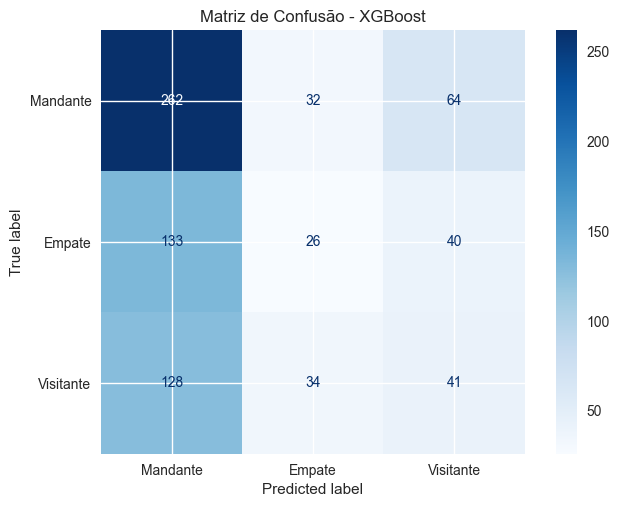

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression


# Modelo (XGBoost é rei nesse problema)
model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Vitória Mandante', 'Empate', 'Vitória Visitante']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Mandante', 'Empate', 'Visitante']).plot(cmap='Blues')
plt.title('Matriz de Confusão - XGBoost')
plt.show()